## Imports

In [1]:
# imports

import pandas as pd
import numpy as np
import json
from pandas import json_normalize
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.spatial import distance_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
import matplotlib.cm as cm
import os
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cm.Dark2.colors)
from TrackReconstruction_functions import *


## Functions

In [2]:
#-----GET VERTEX------
def get_vertex(part, eid):

    x_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_x.iloc[0]
    y_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_y.iloc[0]
    z_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_z.iloc[0]

    return x_vertex, y_vertex, z_vertex

In [3]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

In [14]:
def get_vertex_df(label_dir, five_full_df, zero_one_full_df, nodiff_full_df):
    five_lookup = five_full_df.set_index("event_id")
    zero_one_lookup = zero_one_full_df.set_index("event_id")
    nodiff_lookup = nodiff_full_df.set_index("event_id")
    rows = []
    vertex_dict = {}
    for file in os.listdir(label_dir):
        eid_str = file.split("_")[1]
        eid = int(eid_str)
        diffusion = file.split("_")[6]
        dims = file.split("_")[7][:2]
        dim_1, dim_2 = dims[0], dims[1]
        key = f"{eid_str}_{diffusion}"

        if diffusion == "5.0percent":
            lookup = five_lookup
        elif diffusion == "0.1percent":
            lookup = zero_one_lookup
        else:
            lookup = nodiff_lookup

        if eid not in lookup.index:
            print(f"No match for {eid}, skipping")
            continue

        row = lookup.loc[eid]
        true_vertex = row["vertex"]
        raw = row["axis_limits"]
        if raw is None:
            print(f"No axis limits for event {eid}, skipping")
            continue
        limits = json.loads(raw)

        if dims not in limits:
            print(f"No limits for {dims} in event {eid}, skipping")
            continue

        xlim = limits[dims]["xlim"]
        ylim = limits[dims]["ylim"]

        if key not in vertex_dict:
            vertex_dict[key] = {
                "diffusion": diffusion,
                "x_true": None, "y_true": None, "z_true": None,
                f"{dim_1}_pred": [], f"{dim_2}_pred": [],
                "confidence": []
            }

        file_path = os.path.join(label_dir, file)
        with open(file_path, "r") as f:
            lines = f.readlines()

        best_line = None
        best_conf = -1
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 6:
                confidence = float(parts[-1])
            else:
                confidence = 1.0
            if confidence > best_conf:
                best_conf = confidence
                best_line = parts

        if best_line:
            cx, cy = float(best_line[1]), float(best_line[2])
            x_phys = cx * (xlim[1] - xlim[0]) + xlim[0]
            y_phys = (1 - cy) * (ylim[1] - ylim[0]) + ylim[0]

            rows.append({
                "event_id": eid,
                "diffusion": diffusion,
                "dim": dims,
                "x_true": true_vertex[0],
                "y_true": true_vertex[1],
                "z_true": true_vertex[2],
                f"{dim_1}_pred": x_phys,
                f"{dim_2}_pred": y_phys,
                "confidence": best_conf
            })

    vertex_df = pd.DataFrame(rows)
    vertex_df.head()
    return vertex_df

In [5]:
def plot_predicted(eid, diffusion, vertex_df, z_shift):

    #getting hits info
    h5_file_key = int((int(eid)/120)-1)
    
    if diffusion == "nodiff":
        h5_diff = "nexus"
    else:
        h5_diff = f"{diffusion}_smear"
        
    h5_file_name = f"events_45_135_{h5_diff}_{h5_file_key}.h5"
    h5_dir = f"/mnt/d/events_45_135/simulated_data/1bar/{diffusion}"
    h5_path = os.path.join(h5_dir, h5_file_name)
    
    hits_df = pd.read_hdf(h5_path, "MC/hits")

    #getting row info
    vertex_row = vertex_df[(vertex_df["event_id"] == eid) & (vertex_df["diffusion"] == diffusion)]

    #getting dimensions
    dims_df = vertex_row[["x_pred", "y_pred", "z_pred"]]
    dims_df = dims_df.rename(columns={
        "x_pred": "x",
        "y_pred": "y",
        "z_pred": "z"})
    
    valid_dims = [
        col for col in dims_df.columns
        if dims_df[col].notna().any()
    ]
    
    dims = []
    for i in range(len(valid_dims)):
        for j in range(i+1, len(valid_dims)):
            dim1 = valid_dims[i]
            dim2 = valid_dims[j]
            dims.append(dim1+dim2)

    #plotting
    for i in dims:
        dim1 = i[0]
        dim2 = i[1]
        
        x_pred = vertex_row[f"{dim1}_pred"]
        y_pred = vertex_row[f"{dim2}_pred"]

        x_true = vertex_row[f"{dim1}_true"]
        y_true = vertex_row[f"{dim2}_true"]

        event_hits = hits_df[hits_df["event_id"] == eid]
        x_hits = event_hits[dim1]
        y_hits = event_hits[dim2]

        if (dim2 == "z") & (diffusion != "nodiff"):
            y_hits = y_hits - z_shift

        fig = plt.figure(figsize=(5,5))

        plt.scatter(x_hits, y_hits, alpha=0.02, s=10, c=event_hits.energy, cmap="Greys_r")
        plt.scatter(x_pred, y_pred, color="blue", s=20, label="Predicted Vertex")
        plt.scatter(x_true, y_true, color="red", s=20, label="True Vertex")

        plt.title(f"{dim1 + dim2} Projection Event {eid}")
        plt.legend()
        plt.xlabel(dim1)
        plt.ylabel(dim2)
        plt.grid(True, alpha=0.3, linewidth=0.5)

        plt.show()
        

In [6]:
def plot_hist_dist(vertex_df, title):
    distances = []
    
    for index, data in vertex_df.iterrows():
        pred_cols = {"x": data.get("x_pred"),
                     "y": data.get("y_pred"),
                     "z": data.get("z_pred")}
        
        true_cols = {"x": data.get("x_true"),
                     "y": data.get("y_true"),
                     "z": data.get("z_true")}

        valid_dims = [dim for dim, val in pred_cols.items()
                        if pd.notna(val)]

        dim_pairs = [
            (valid_dims[i], valid_dims[j])
            for i in range(len(valid_dims))
            for j in range(i+1, len(valid_dims))
        ]

        for dim1, dim2 in dim_pairs:
            xp = pred_cols[dim1]
            yp = pred_cols[dim2]

            xt = true_cols[dim1]
            yt = true_cols[dim2]

            dist = np.sqrt(((xt-xp)**2)+((yt-yp)**2))

            distances.append(dist)
            
    bins = int(np.ceil(np.log2(len(distances)) + 1))
    plt.figure(figsize=(5,5))
    plt.hist(distances, bins=bins)
    plt.title(title)
    plt.xlabel("Distance between predicted and true (2D)")
    plt.ylabel("Counts")

In [7]:
def percent_threshold(vertex_df, min_dist, max_dist):
    distances = []
    
    for index, data in vertex_df.iterrows():
        pred_cols = {"x": data.get("x_pred"),
                     "y": data.get("y_pred"),
                     "z": data.get("z_pred")}
        
        true_cols = {"x": data.get("x_true"),
                     "y": data.get("y_true"),
                     "z": data.get("z_true")}
        valid_dims = [dim for dim, val in pred_cols.items()
                        if pd.notna(val)]
        dim_pairs = [
            (valid_dims[i], valid_dims[j])
            for i in range(len(valid_dims))
            for j in range(i+1, len(valid_dims))
        ]
        for dim1, dim2 in dim_pairs:
            xp = pred_cols[dim1]
            yp = pred_cols[dim2]
            xt = true_cols[dim1]
            yt = true_cols[dim2]
            dist = np.sqrt((xt - xp)**2 + (yt - yp)**2)
            distances.append(dist)

    distances = np.array(distances)
    within_threshold = np.sum((distances <= max_dist) & (distances > min_dist))
    total_events = len(distances)
    percent = (within_threshold / total_events) * 100 if total_events > 0 else 0
    return percent

In [8]:
def percent_pie_chart(vertex_df, distance_ranges, title):
    percentages = []
    labels = []
    colors = plt.cm.Set3(np.linspace(0, 1, len(distance_ranges) + 1))
    for i, dist in enumerate(distance_ranges):
        if i==0:
            min_dist = 0
        else:
            min_dist = distance_ranges[i-1]

        percent = percent_threshold(vertex_df, min_dist, dist)
        label = f"{min_dist}-{dist} mm"
        percentages.append(percent)
        labels.append(label)

    greater = 100 - sum(percentages)
    percentages.append(greater)
    labels.append(f">{max(distance_ranges)} mm")

    fig, ax = plt.subplots(figsize=(6,6))
    wedges, texts, autotexts = ax.pie(
        percentages,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops={"edgecolor": "black", "linewidth": 1},
        autopct=lambda pct: f"{pct:.1f}%" if pct >= 5 else "",       # automatically shows percent
        pctdistance=0.7,          # distance of percent text from center
        labeldistance=1.1 
    )
    
    ax.legend(
        wedges,
        labels,
        title="Distance from True Vertex",
        loc="upper right",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=11
    )
            
    ax.set_title(title)
    plt.tight_layout()
    
    plt.show()

## Creating Dataframes

In [9]:
nodiff_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/nodiff_full.jsonl", lines=True)

In [10]:
five_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/5.0percent_full.jsonl", lines=True)

In [11]:
zero_one_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/0.1percent_full.jsonl", lines=True)

In [12]:
nodiff_full_df.head()

,file,event_id,vertex,energies,vectors_true,cos12_true,vectors_reco,cos12_reco,vertex_1mm,vectors_1mm,...,vertex_3mm,vectors_3mm,cos12_3mm,vertex_4mm,vectors_4mm,cos12_4mm,vertex_5mm,vectors_5mm,cos12_5mm,axis_limits
0,events_45_135_nexus_234.h5,28200,"[89.1703643799, -254.9182891846, 770.6735839844]","[1.7819108962999999, 1.2180942297]","[{'endpoint': [89.0084848129, -254.4816803448,...",-0.454866,"[{'endpoint': [79.4565200806, -257.6108093262,...",-0.487951,"[88.8614400221, -255.1000646298, 769.7400297928]","[{'endpoint': [79.4565200806, -257.6108093262,...",...,"[91.0957145097, -252.8572828948, 771.6959733187]","[{'endpoint': [79.4565200806, -257.6108093262,...",-0.224220,"[87.6792411013, -258.1282667747, 768.8100939149]","[{'endpoint': [79.4565200806, -257.6108093262,...",-0.563375,"[91.2445588438, -250.3688698714, 770.6511956273]","[{'endpoint': [79.4565200806, -257.6108093262,...",-0.181575,"{""xy"": {""xlim"": [-955.565441, 138.76025], ""yli..."
1,events_45_135_nexus_234.h5,28201,"[-54.7433357239, -2966.4846191406, 1998.483642...","[1.3792482615, 1.6207501888]","[{'endpoint': [-55.0258456975, -2965.933789181...",0.454660,"[{'endpoint': [-45.2098693848, -2955.670654296...",0.492365,"[-54.9185485875, -2966.6860532306, 1999.447346...","[{'endpoint': [-45.2098693848, -2955.670654296...",...,"[-56.5119267646, -2965.4762509017, 1996.280172...","[{'endpoint': [-45.2098693848, -2955.670654296...",0.539460,"[-53.5711319597, -2963.9692040412, 2001.364376...","[{'endpoint': [-45.2098693848, -2955.670654296...",0.248632,"[-53.1260590065, -2966.1730929525, 1993.762692...","[{'endpoint': [-57.8963165283, -2961.351806640...",0.623635,"{""xy"": {""xlim"": [-209.291711, 698.003381], ""yl..."
2,events_45_135_nexus_234.h5,28202,"[314.8579406738, 2711.1049804688, -552.6751708...","[1.7307546139, 1.2692490816]","[{'endpoint': [315.1770008584, 2710.8416303357...",0.901132,"[{'endpoint': [318.617401123, 2706.1215820312,...",0.977016,"[314.9884042343, 2711.7930282912, -551.9613295...","[{'endpoint': [318.617401123, 2706.1215820312,...",...,"[314.8621330058, 2710.2448115933, -549.8011333...","[{'endpoint': [318.617401123, 2706.1215820312,...",0.959663,"[311.09715809, 2712.4640880363, -552.7718196291]","[{'endpoint': [319.6283874512, 2705.7192382812...",0.959133,"[313.0518859224, 2715.5312125078, -554.1403112...","[{'endpoint': [319.6283874512, 2705.7192382812...",0.905683,"{""xy"": {""xlim"": [-489.143622, 594.352484], ""yl..."
3,events_45_135_nexus_234.h5,28203,"[373.4661560059, 349.9651794434, -638.7649536133]","[1.3620698452, 1.6379346848]","[{'endpoint': [373.3819762052, 349.9801794078,...",-0.087843,"[{'endpoint': [362.6803894043, 367.664855957, ...",-0.100428,"[372.5930854146, 349.8860211905, -638.2838281477]","[{'endpoint': [362.6803894043, 367.664855957, ...",...,"[372.0761805044, 350.1919811463, -636.1160804391]","[{'endpoint': [362.6803894043, 367.664855957, ...",-0.053132,"[372.2966744915, 349.7984995026, -634.9433661441]","[{'endpoint': [362.6803894043, 367.664855957, ...",0.036802,"[376.1542189504, 346.5133228467, -636.3444157304]","[{'endpoint': [370.5117797852, 354.9004516602,...",0.497040,"{""xy"": {""xlim"": [245.249118, 1252.17001], ""yli..."
4,events_45_135_nexus_234.h5,28204,"[-115.1897201538, 1587.9614257812, -2769.75268...","[1.7367283106, 1.2632689476]","[{'endpoint': [-115.1164501072, 1587.470775480...",-0.290744,"[{'endpoint': [-112.6763076782, 1581.935302734...",-0.228110,"[-115.2088567973, 1587.5336735901, -2768.84899...","[{'endpoint': [-112.6763076782, 1581.935302734...",...,"[-114.4249485011, 1590.188371066, -2771.611674...","[{'endpoint': [-101.9808502197, 1599.754760742...",-0.193759,"[-115.005565181, 1585.3430816316, -2766.734348...","[{'endpoint': [-112.6763076782, 1581.935302734...",-0.308333,"[-112.9192123086, 1587.1515403466, -2774.13319...","[{'endpoint': [-101.9808502197, 1599.754760742...",-0.042227,"{""xy"": {""xlim"": [-639.444357, 218.068686], ""yl..."


In [15]:
vertex_df_5k = get_vertex_df("/home/rei/NEXT/vertex_ML/yolo_data/detect/predict_5k/labels", five_full_df, zero_one_full_df, nodiff_full_df)
vertex_df_30k = get_vertex_df("/home/rei/NEXT/vertex_ML/yolo_data/detect/predict_30k/labels", five_full_df, zero_one_full_df, nodiff_full_df)

No match for 25911, skipping
No match for 31841, skipping
No match for 49135, skipping
No match for 83280, skipping
No match for 5265, skipping
No match for 70969, skipping
No match for 53223, skipping
No match for 29540, skipping
No match for 33226, skipping
No match for 61788, skipping
No match for 5176, skipping
No match for 59174, skipping
No match for 45013, skipping
No match for 92642, skipping
No match for 53190, skipping
No match for 96415, skipping
No match for 10158, skipping
No match for 77470, skipping
No match for 71271, skipping
No match for 114374, skipping
No match for 53223, skipping
No match for 105452, skipping
No match for 35896, skipping
No match for 94592, skipping


## Analysis

In [25]:
print(f"5k percent predicted: {(len(vertex_df_5k)/1000)*100}%")
print(f"30k percent predicted: {(len(vertex_df_30k)/3000)*100}%")

5k percent predicted: 6.7%
30k percent predicted: 11.0%


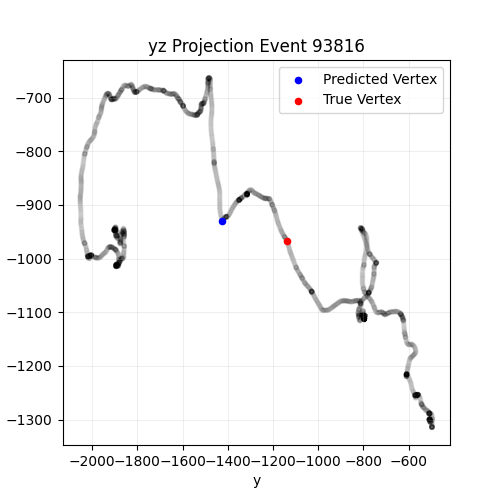

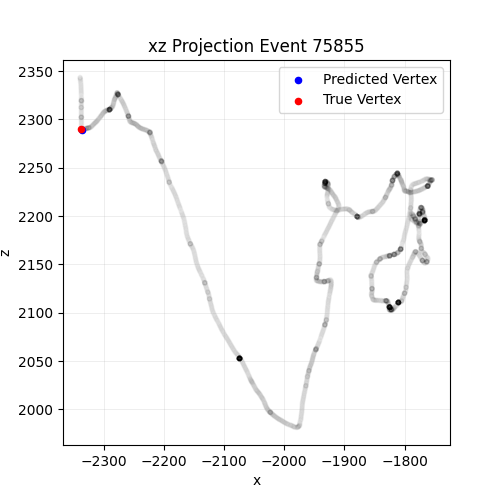

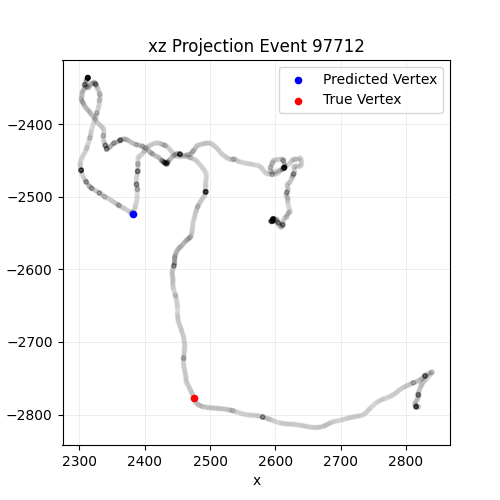

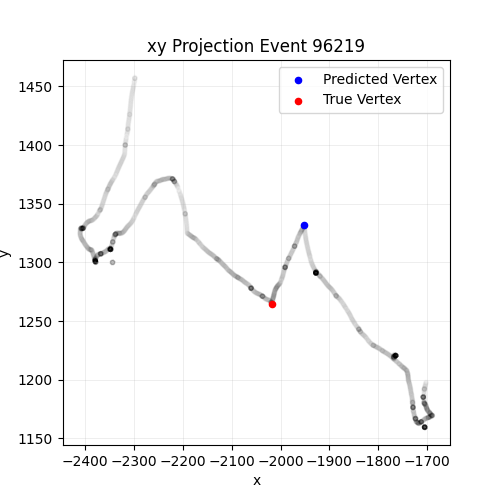

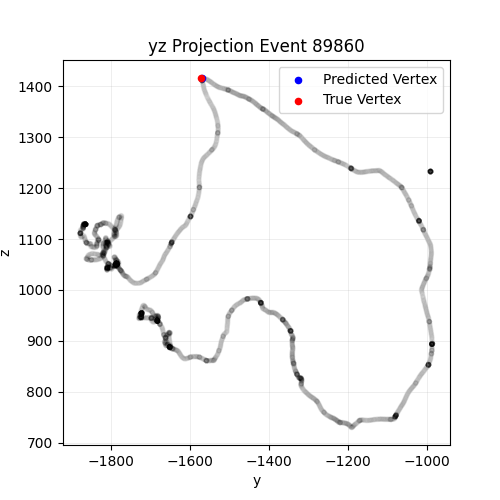

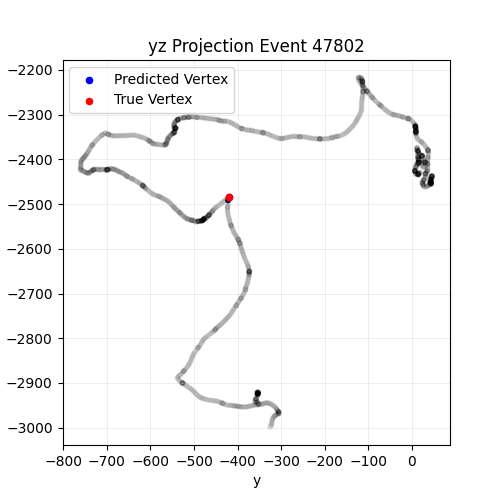

In [17]:
%matplotlib widget
count = 0
for index, row in vertex_df_5k.iterrows():
    eid = row["event_id"]
    diffusion = row["diffusion"]
    plot_predicted(eid, diffusion, vertex_df_5k, z_shift)
    count += 1
    if count > 5:
        break
    

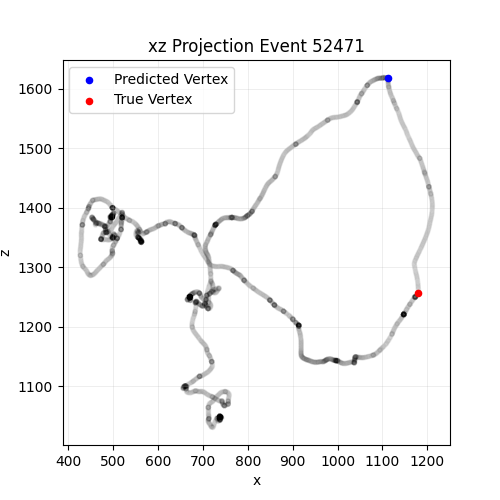

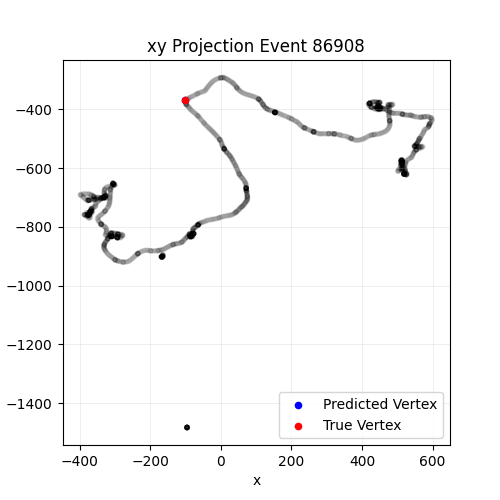

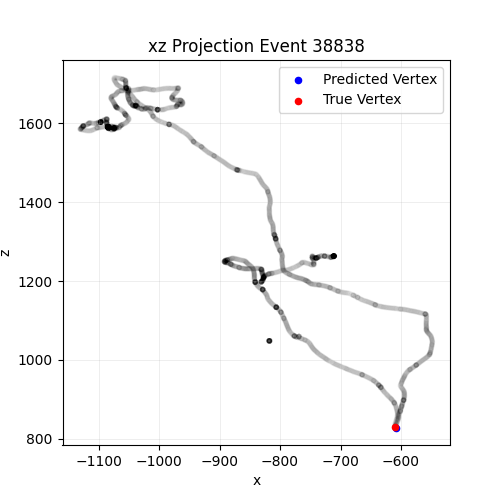

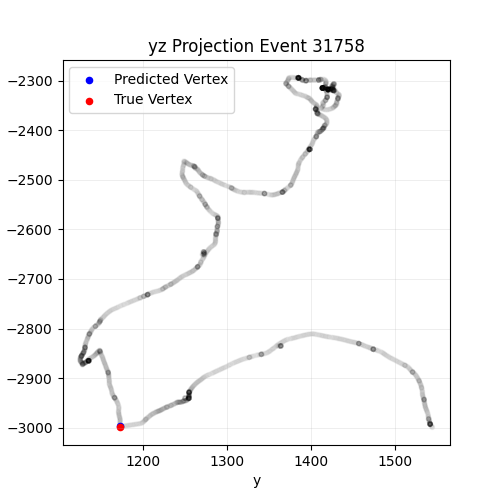

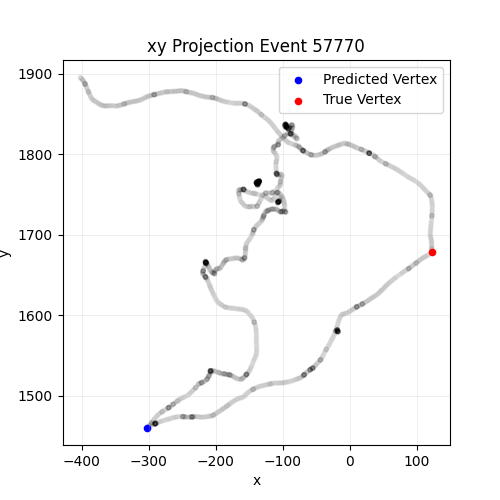

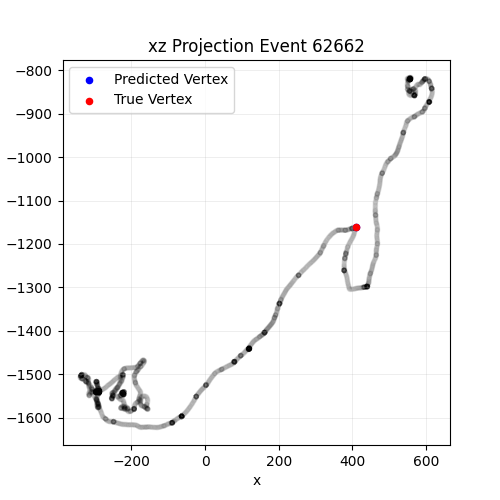

In [18]:
%matplotlib widget
count = 0
for index, row in vertex_df_30k.iterrows():
    eid = row["event_id"]
    diffusion = row["diffusion"]
    plot_predicted(eid, diffusion, vertex_df_30k, z_shift)
    count += 1
    if count > 5:
        break

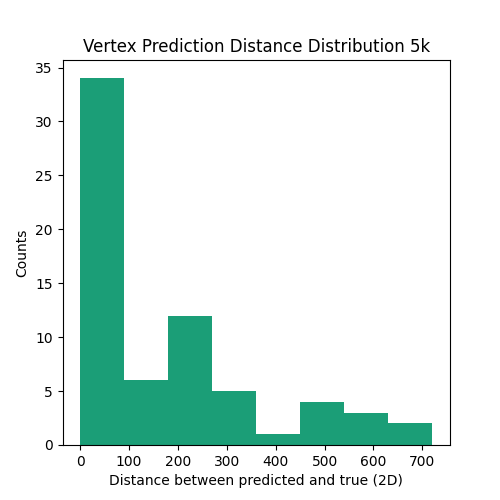

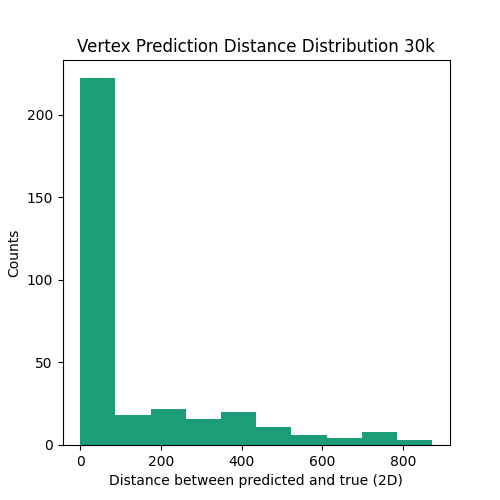

In [19]:
plot_hist_dist(vertex_df_5k, "Vertex Prediction Distance Distribution 5k")
plot_hist_dist(vertex_df_30k, "Vertex Prediction Distance Distribution 30k")

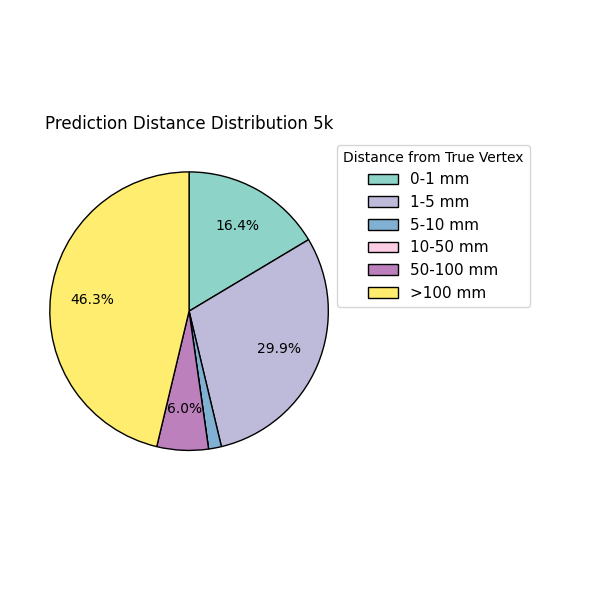

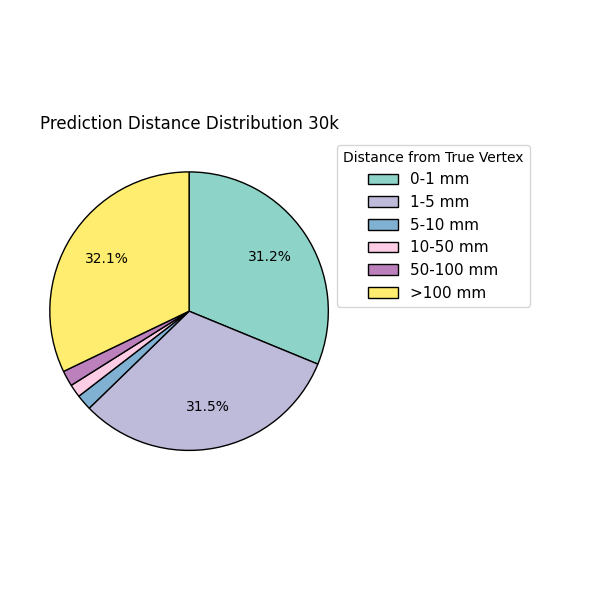

In [20]:
distance_ranges = [1, 5, 10, 50, 100]
percent_pie_chart(vertex_df_5k, distance_ranges, "Prediction Distance Distribution 5k")
percent_pie_chart(vertex_df_30k, distance_ranges, "Prediction Distance Distribution 30k")